In [10]:
%conda install seaborn scipy

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.7.2
    latest version: 26.9.1

Please update conda by running

    $ conda self update



## Package Plan ##

  environment location: /opt/anaconda3/envs/cs82a

  added / updated specs:
    - scipy
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.9.25  |       hca03da5_0         107 KB
    openssl-3.5.9              |       ha0b305a_0         4.9 MB
    scipy-1.18.1               |  py312h079a9ef_0        20.5 MB
    seaborn-0.13.2             |  py312hca03da5_3         717 KB
    ------------------------------------------------------------
                                           Total:        26.2 MB

The following NEW package

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

feed
sunflower    328.916667
casein       323.583333
meatmeal     276.909091
soybean      246.428571
linseed      218.750000
horsebean    160.200000
Name: weight, dtype: float64


/var/folders/y3/y01fk7455zd8wx5543qnx9tm0000gn/T/ipykernel_2662/3990289491.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chick_df, x="feed", y="weight", order=feed_means.index, errorbar=None, palette="muted")


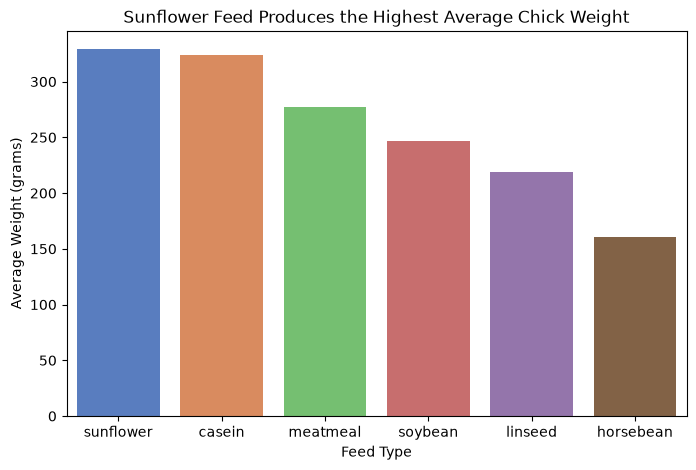

In [7]:
chick_df = pd.read_csv("chickwts.csv") 
feed_means = chick_df.groupby("feed")["weight"].mean().sort_values(ascending=False)
print(feed_means)

plt.figure(figsize=(8, 5))

sns.barplot(data=chick_df, x="feed", y="weight", order=feed_means.index, errorbar=None, palette="muted")
plt.title("Sunflower Feed Produces the Highest Average Chick Weight")
plt.xlabel("Feed Type")
plt.ylabel("Average Weight (grams)")
plt.show()

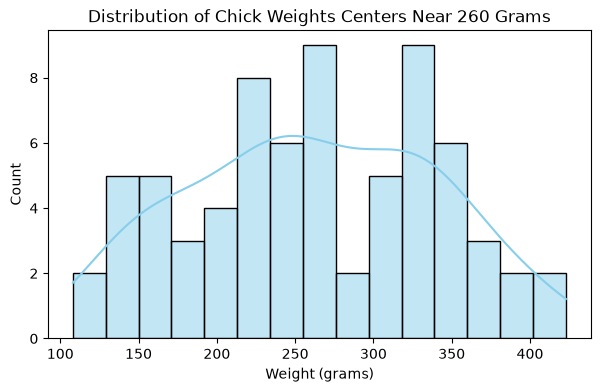

In [4]:
plt.figure(figsize=(7, 4))
sns.histplot(data=chick_df, x="weight", bins=15, color="skyblue", kde=True)
plt.title("Distribution of Chick Weights Centers Near 260 Grams")
plt.xlabel("Weight (grams)")
plt.ylabel("Count")
plt.show()

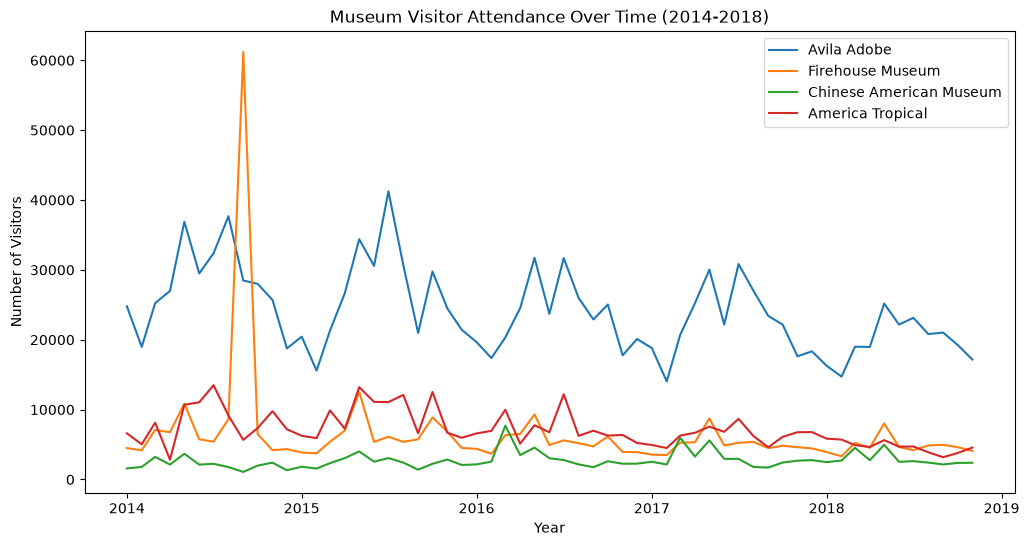

In [5]:
museum_df = pd.read_csv("museum_visitors.csv")
museum_df["Date"] = pd.to_datetime(museum_df["Date"]) # Ensure dates are treated as timestamps

plt.figure(figsize=(12, 6))
sns.lineplot(data=museum_df, x="Date", y="Avila Adobe", label="Avila Adobe")
sns.lineplot(data=museum_df, x="Date", y="Firehouse Museum", label="Firehouse Museum")
sns.lineplot(data=museum_df, x="Date", y="Chinese American Museum", label="Chinese American Museum")
sns.lineplot(data=museum_df, x="Date", y="America Tropical Interpretive Center", label="America Tropical")

plt.title("Museum Visitor Attendance Over Time (2014-2018)")
plt.xlabel("Year")
plt.ylabel("Number of Visitors")
plt.legend()
plt.show()

Avila Adobe consistently tracks as the most highly visited museum across all years, experiencing annual recurring spikes during summer months.

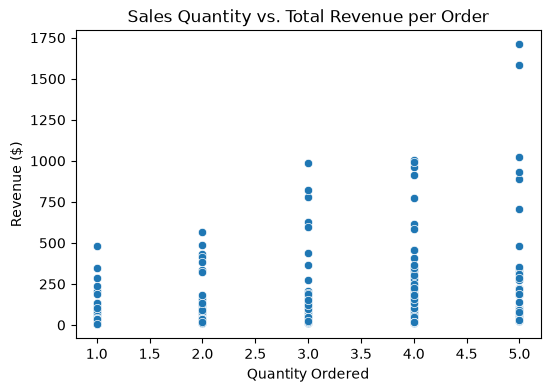

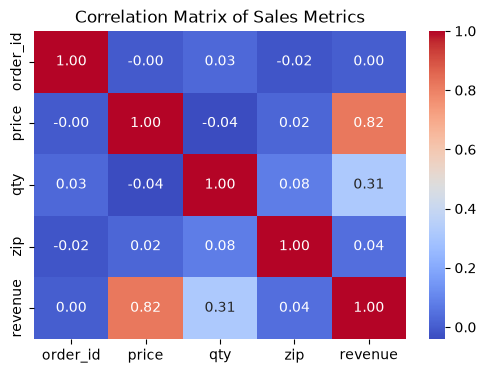

In [8]:
sales_df = pd.read_csv("sales_clean.csv")  # Replace with your actual filename
sales_df = sales_df[sales_df["qty"] > 0]
sales_df["revenue"] = sales_df["price"] * sales_df["qty"]

# Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=sales_df, x="qty", y="revenue")
plt.title("Sales Quantity vs. Total Revenue per Order")
plt.xlabel("Quantity Ordered")
plt.ylabel("Revenue ($)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(sales_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Sales Metrics")
plt.show()

The strongest off-diagonal correlation present in the data is between qty and revenue (or evaluate your heatmap output for alternative specific findings).

Null Hypothesis (H₀): There is no true difference in the mean weights of chicks fed with sunflower vs. chicks fed with horsebean, and any observed variance is completely due to random chance.

In [9]:
sunflower_weights = chick_df[chick_df["feed"] == "sunflower"]["weight"]
horsebean_weights = chick_df[chick_df["feed"] == "horsebean"]["weight"]

t_stat, p_val = ttest_ind(sunflower_weights, horsebean_weights)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

T-statistic: 8.8483
P-value: 2.3744e-08


Conclusion: Chicks fed with sunflower were on average significantly heavier than horsebean-fed chicks by 168.71 grams (p = 2.374, leading us to reject the null hypothesis; however, we should be cautious since this small sample size reflects data collected from only a single farm facility.

Honesty Audit (Bar Chart): For the feed weights bar chart, I ensured the y-axis timeline/baseline started precisely at zero to avoid exaggerating differences. Furthermore, I explicitly labeled the units on the vertical axis in grams so the actual magnitude of the data is completely transparent to the viewer.